# General

For more informations, see the documentation *LLM and GenAI*.

# Import & Configs

In [1]:
import json
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
%reload_ext autoreload
%autoreload 2

from src.preprocessing.query_processing import clean_query

# Questions Set

In [4]:
with open(
    "../data/evaluations/gold_questions.json"
) as f:

    questions = json.load(f)

questions

[{'question': 'What is glioblastoma?'},
 {'question': 'How is glioblastoma prognosis evaluated?'},
 {'question': 'What MRI techniques are used for glioblastoma?'},
 {'question': 'What is peritumoral edema?'},
 {'question': 'What is pseudoprogression?'},
 {'question': 'How is tumor progression detected?'},
 {'question': 'What biomarkers are associated with glioblastoma?'},
 {'question': 'What are the limitations of MRI in glioma diagnosis?'},
 {'question': 'How is overall survival measured?'},
 {'question': 'What treatments are commonly used for glioblastoma?'}]

# Evaluation Dataframe

In [5]:
df_corpus_eval = pd.DataFrame({
    "Question": [list(q.values())[0] for q in questions],
    "Coverage": None,
    "Difficulty": None,
    "Comments": ""
})

df_corpus_eval

,Question,Coverage,Difficulty,Comments
0,What is glioblastoma?,None,None,
1,How is glioblastoma prognosis evaluated?,None,None,
2,What MRI techniques are used for glioblastoma?,None,None,
3,What is peritumoral edema?,None,None,
4,What is pseudoprogression?,None,None,
5,How is tumor progression detected?,None,None,
6,What biomarkers are associated with glioblastoma?,None,None,
7,What are the limitations of MRI in glioma diag...,None,None,
8,How is overall survival measured?,None,None,
9,What treatments are commonly used for glioblas...,None,None,


# Documents Corpus Upload

In [6]:
def  get_documents_df():
    documents = []
    
    with open("../data/processed/clean_documents.jsonl", "r") as f:
        for line in f:
            documents.append(json.loads(line))

    df = pd.DataFrame(documents)
    return df

In [7]:
df = get_documents_df()
df.head()

,pmid,title,abstract,year,text,journal,mesh,keywords,publication_types,is_review,is_systematic_review,is_meta_analysis,is_guideline,evidence_level
0,42277245,Mapping radiosensitivity in glioblastoma using...,Glioblastoma multiforme (GBM) remains a devast...,2026,Mapping radiosensitivity in glioblastoma using...,Scientific reports,[],"[Glioblastoma (GBM), MR elastography (MRE), Ma...",[Journal Article],False,False,False,False,1
1,42276782,Treatment of Human Glioblastoma Multiforme in ...,The effectiveness and safety of Auger electron...,2026,Treatment of Human Glioblastoma Multiforme in ...,Journal of nuclear medicine : official publica...,[],"[197gHg, Auger electrons, convection-enhanced ...",[Journal Article],False,False,False,False,1
2,42276409,Selective inhibition of ELFN2-containing PP1 h...,Glioblastoma (GBM) frequently develops resista...,2026,Selective inhibition of ELFN2-containing PP1 h...,Cancer letters,[],"[ELFN2-containing PP1, Glioblastoma, alternati...",[Journal Article],False,False,False,False,1
3,42276258,Mitochondria-driven oxidative stress mediates ...,"Cyproconazole (CYPRO), a triazole fungicide wi...",2026,Mitochondria-driven oxidative stress mediates ...,Neurotoxicology,[],"[Cyproconazole, caspase-dependent apoptosis, m...",[Journal Article],False,False,False,False,1
4,42276218,Preclinical feasibility and validation of MRI ...,PURPOSE: Interstitial photodynamic therapy (iP...,2026,Preclinical feasibility and validation of MRI ...,Photodiagnosis and photodynamic therapy,[],"[MRI, glioblastoma, interstitial photodynamic ...",[Journal Article],False,False,False,False,1


# Chunks Upload

In [8]:
def  get_chunks_df():
    documents = []
    
    with open("../data/chunks/chunks.jsonl", "r") as f:
        for line in f:
            documents.append(json.loads(line))

    df = pd.DataFrame(documents)
    return df

In [9]:
chunk_df = get_chunks_df()
chunk_df.head()

,chunk_id,pmid,chunk_index,title,year,evidence_level,is_review,is_systematic_review,is_meta_analysis,is_guideline,text
0,42277245_0,42277245,0,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,Mapping radiosensitivity in glioblastoma using...
1,42277245_1,42277245,1,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,While the link between hypoxia and radiosensit...
2,42277245_2,42277245,2,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,The model can translate MRE-derived stiffness ...
3,42277245_3,42277245,3,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,Our simulations show that biomechanical proper...
4,42277245_4,42277245,4,Mapping radiosensitivity in glioblastoma using...,2026,1,False,False,False,False,The results are compressed vessels with hypo-p...


# Corpus Analysis

In [10]:
def count_sub_list_elements(df, col_name):
    all_elm = []

    for elm_list in df[col_name]:
    
        if isinstance(elm_list, list):
            all_elm.extend(elm_list)

    all_elm = [item.lower() for item in all_elm]
    elm_counts = Counter(all_elm)

    return pd.DataFrame(
        elm_counts.most_common(30),
        columns=[col_name, "count"]
    )

___

In [11]:
len(df)

3307

In [12]:
df["pmid"].nunique()

3307

year
1993       3
1997       1
2000       5
2003       1
2005       1
2006       1
2007       2
2009       1
2010       1
2011       3
2012       4
2013       5
2014       9
2015      18
2016      24
2017      24
2018      31
2019      24
2020      40
2021      72
2022     104
2023     127
2024     225
2025     622
2026    1959
Name: count, dtype: int64

<Axes: xlabel='year'>

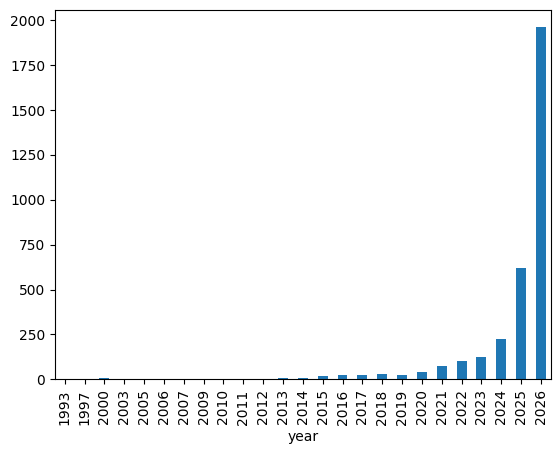

In [13]:
stats = df["year"].value_counts().sort_index()
display(stats)

stats.plot(kind='bar')

evidence_level
1    1510
2     595
3     389
4     813
Name: count, dtype: int64

evidence_level
1    45.660720
2    17.992138
3    11.762927
4    24.584215
Name: proportion, dtype: float64

<Axes: xlabel='evidence_level'>

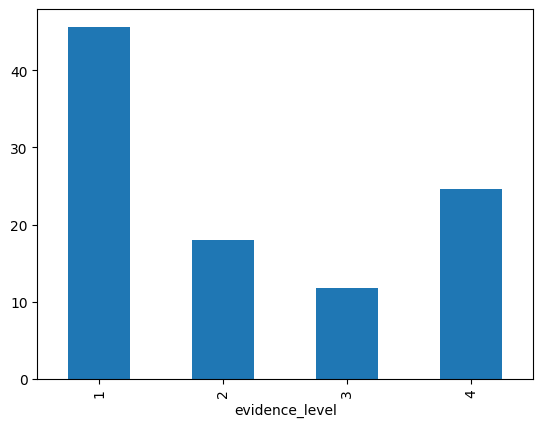

In [14]:
stats = df["evidence_level"].value_counts().sort_index()
display(stats)
print("\n")
stats = (df["evidence_level"].value_counts(normalize=True)*100).sort_index()
display(stats)

stats.plot(kind='bar')

evidence_level,1,2,3,4
year,,,,
2022,0.000000,0.000000,0.163462,0.836538
2023,0.000000,0.000000,0.409449,0.590551
2024,0.000000,0.000000,0.431111,0.568889
2025,0.257235,0.178457,0.245981,0.318328
2026,0.689127,0.242981,0.035733,0.032159


<Axes: xlabel='evidence_level', ylabel='year'>

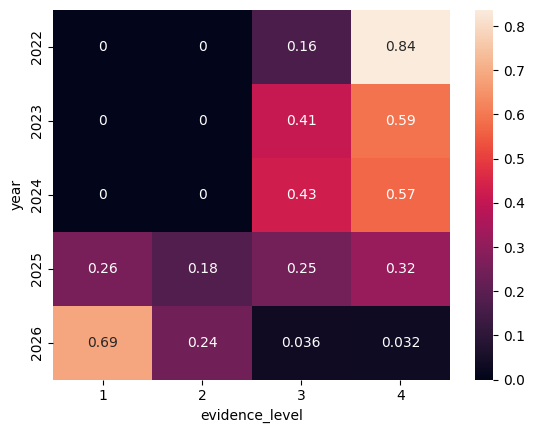

In [15]:
stats = pd.crosstab(df[df["year"]>='2022']["year"], df["evidence_level"], normalize='index')
display(stats) 

sns.heatmap(stats, annot=True)

,publication_types,count
0,journal article,3288
1,systematic review,956
2,review,735
3,meta-analysis,669
4,case reports,302
5,practice guideline,132
6,"research support, non-u.s. gov't",96
7,english abstract,72
8,comparative study,51
9,multicenter study,40


<Axes: >

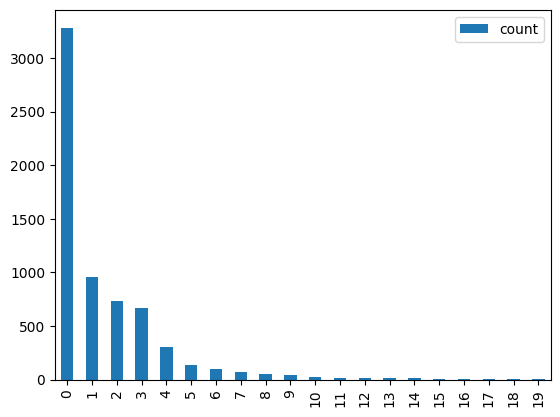

In [16]:
stats = count_sub_list_elements(df, "publication_types").head(20).sort_index()
display(stats)

stats.plot(kind='bar')

,publication_types,count
0,journal article,1952
1,review,545
2,case reports,219
3,systematic review,124
4,meta-analysis,59
5,english abstract,45
6,multicenter study,33
7,preprint,19
8,"research support, non-u.s. gov't",15
9,observational study,14


<Axes: >

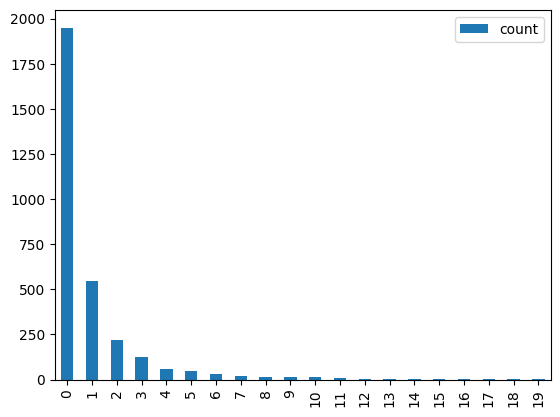

In [17]:
stats = count_sub_list_elements(df[df["year"] == '2026'], "publication_types").head(20).sort_index()
display(stats)

stats.plot(kind='bar')

journal
Acta neurochirurgica                                                                                         46
BMC cancer                                                                                                   30
Cancers                                                                                                      49
Child's nervous system : ChNS : official journal of the International Society for Pediatric Neurosurgery     37
Clinical neurology and neurosurgery                                                                          34
Cureus                                                                                                       48
Frontiers in endocrinology                                                                                   37
Frontiers in immunology                                                                                      36
Frontiers in oncology                                                                           

<Axes: xlabel='journal'>

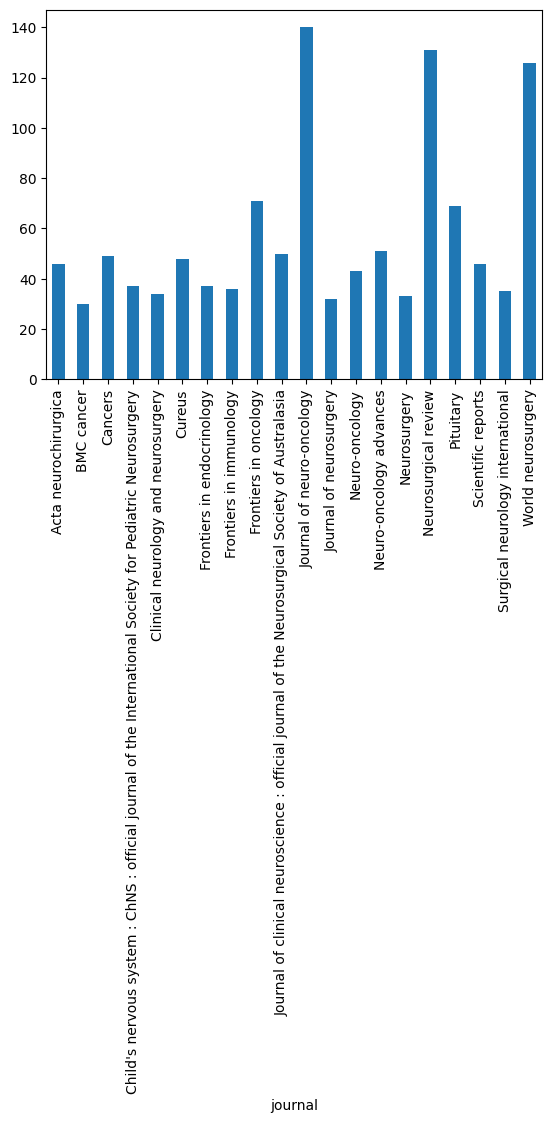

In [18]:
stats = df["journal"].value_counts().head(20).sort_index()
display(stats)

stats.plot(kind='bar')

,mesh,count
0,humans,2031
1,female,736
2,male,678
3,adult,543
4,middle aged,525
5,treatment outcome,404
6,aged,403
7,retrospective studies,355
8,prognosis,261
9,animals,226


<Axes: >

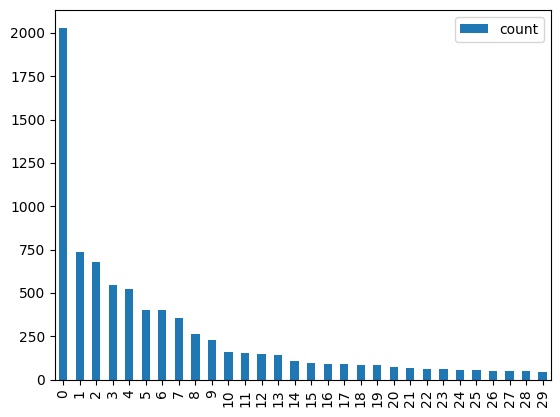

In [19]:
stats = count_sub_list_elements(df, "mesh").head(30).sort_index()
display(stats)

stats.plot(kind='bar')

,keywords,count
0,glioblastoma,530
1,meningioma,355
2,glioma,297
3,meta-analysis,202
4,pituitary adenoma,132
5,systematic review,114
6,radiotherapy,89
7,magnetic resonance imaging,78
8,immunotherapy,78
9,prognosis,77


<Axes: >

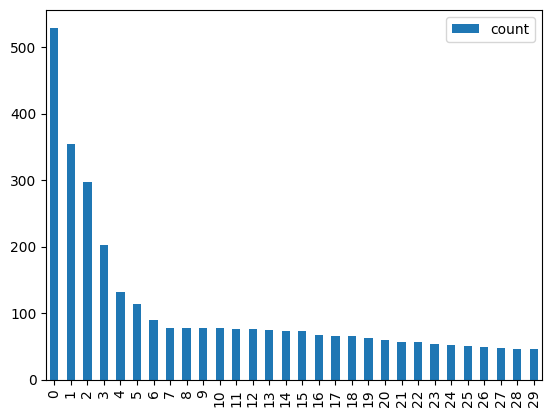

In [20]:
stats = count_sub_list_elements(df, "keywords").head(30).sort_index()
display(stats)

stats.plot(kind='bar')

0       1642
1       2647
2       1319
3       2416
4       2166
        ... 
3302    1249
3303    2008
3304    1398
3305     728
3306    2041
Name: text_length, Length: 3307, dtype: int64

<Axes: ylabel='Frequency'>

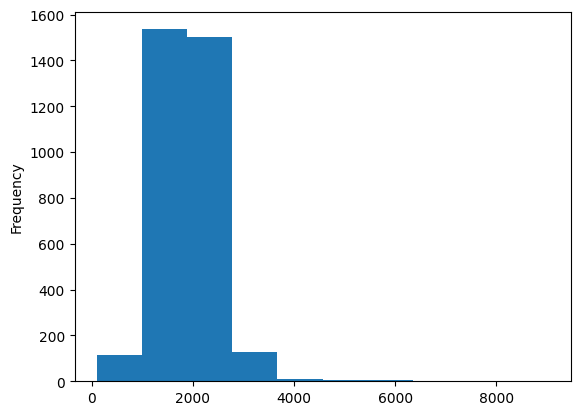

In [21]:
df["text_length"] = df["text"].str.len()
display(df["text_length"])

df["text_length"].plot(kind='hist')

The document corpus is good, with a high evidence rate for the articles and many recent studies.

# Chunks Analysis

In [22]:
len(chunk_df)

22283

In [23]:
chunk_df["chunk_length"] = (
    chunk_df["text"].apply(len)
)

In [24]:
chunk_df["chunk_length"].describe()

count    22283.000000
mean       423.734057
std         89.761336
min         45.000000
25%        377.000000
50%        428.000000
75%        471.000000
max       3521.000000
Name: chunk_length, dtype: float64

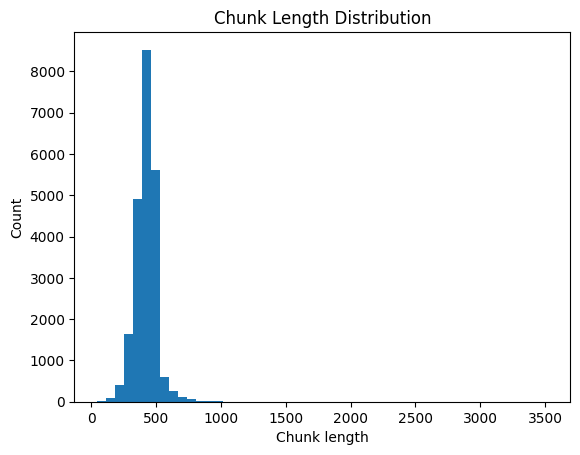

In [25]:
plt.hist(
    chunk_df["chunk_length"],
    bins=50
)

plt.xlabel("Chunk length")

plt.ylabel("Count")

plt.title("Chunk Length Distribution")

plt.show()

<Axes: ylabel='chunk_length'>

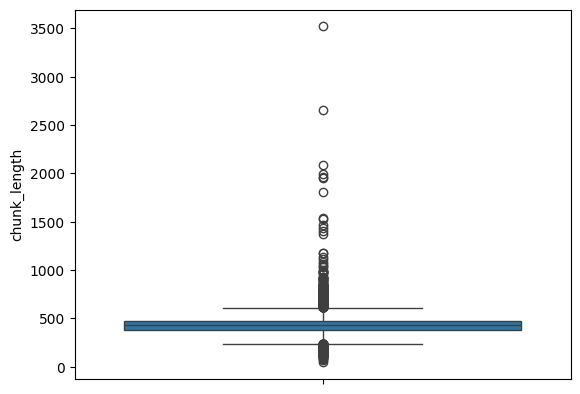

In [26]:
sns.boxplot(data=chunk_df["chunk_length"])

# Research In Corpus

In [44]:
def search_corpus(keyword, df, n=10):

    matches = df[
        df["text"]
        .str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    return matches[
        ["pmid", "title", "year", "evidence_level"]
    ].head(n)

In [29]:
pd.set_option('display.max_colwidth', None)

In [45]:
search_corpus(
    "glioblastoma",
    df
)

,pmid,title,year,evidence_level
0,42277245,Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling,2026,1
1,42276782,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,2026,1
2,42276409,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,2026,1
3,42276258,"Mitochondria-driven oxidative stress mediates Cyproconazole-induced genotoxicity, caspase-dependent apoptosis, and glial neuroinflammation in Human neuronal and glial cell lines",2026,1
4,42276218,Preclinical feasibility and validation of MRI thermometry dedicated to interstitial photodynamic therapy of glioblastoma,2026,1
5,42276053,Patient-derived organoids predict personalized drug response and reveal alternative therapeutic options in glioblastoma,2026,1
6,42275821,Intention-treated water inhibits migration of human glioblastoma cells via downregulation of motility-associated proteins,2026,1
7,42275231,DNA methylation in glioblastoma: insights from single-cell epigenomics,2026,2
8,42275218,Amplification of MED30 at chromosome 8q24 reprograms MYC binding to low-affinity oncogenic enhancers in cancer cells,2026,1
9,42274693,Cryogenic Electron Microscopy of Extracellular Vesicles from Temozolomide-Treated Glioblastoma Cells Reveals Great Morphological Heterogeneity,2026,1


In [46]:
search_corpus(
    "pseudoprogression",
    df
)

,pmid,title,year,evidence_level
210,42162948,"Impact on survival of glioblastoma patient's in relation to the imaging of the peri-surgical area: a multi-parametric diffusion MRI, perfusion MRI and [11C]MET PET study",2026,1
247,42073593,"Extracellular Vesicle-Associated miRNAs in Glioblastoma: Mechanisms, Biomarkers, Therapies, and Links to Neurodegeneration",2026,2
286,41916447,Chemical exchange saturation transfer (CEST) imaging reveals tumor-specific molecular changes in adult gliomas after radiotherapy,2026,1
314,41803972,"Radiomics in glioblastoma recurrence: advances in prediction, localization, and differentiation from treatment-related effects",2026,2
363,42199889,Case Report: Beyond two years: a neurosurgical review of prolonged survival and late recurrence in IDH-wildtype GBM,2026,1
380,42192798,Evolving Landscape of Glioblastoma Research: Integrating Therapeutic Advances and Diagnostic Frontiers,2026,2
706,40768078,Artificial intelligence algorithms for differentiating pseudoprogression from true progression in high-grade gliomas: A systematic review and meta-analysis,2025,4
798,39055895,Hypoxia-inducible factor 1alpha and vascular endothelial growth factor in Glioblastoma Multiforme: a systematic review going beyond pathologic implications,2024,3
802,38992848,Perioperative imaging predictors of tumor progression and pseudoprogression: A systematic review,2024,3
896,35535984,Circulating Tumor DNA in Adults With Glioma: A Systematic Review and Meta-Analysis of Biomarker Performance,2022,4


In [47]:
search_corpus(
    "overall survival",
    df
)

,pmid,title,year,evidence_level
13,42273096,"Association of TERT promoter mutation and MGMT methylation with MRI features and overall survival in glioblastoma, IDH-wildtype",2026,1
19,42271032,The Tumor-suppressive role of CNTNAP2 in glioma: Dual regulation of the NDN-ERK axis and M2 macrophage polarization,2026,1
20,42270868,Clinicoradiological differentiation of TERT promoter-mutant molecular glioblastoma versus histological glioblastoma: a single-center cohort study of 105 IDH-wildtype tumors,2026,1
25,42268435,Comparison between molecular and histological IDH-wild-type glioblastoma and extensive subgroup analysis of IDH-wild-type astrocytic tumors without genomic glioblastoma-defining alterations,2026,1
29,42265433,Survival after hypofractionated radiation versus standard radiation in glioblastoma by MGMT promoter methylation status and age: an analysis of the national cancer database,2026,1
34,42264131,The O‑GlcNAcase inhibition by Thiamet G disrupts the AngioMatrix signature of the Glioblastoma secretome in silico and impairs its angiogenic capacity in vitro,2026,1
43,42260484,FAM135B suppresses glioblastoma angiogenesis via stabilizing the IKK complex and inactivating the NF-kappaB/IL-6 signaling pathway,2026,1
47,42258967,Optimal clinicogenetic criteria for post-operative re-irradiation in recurrent glioblastoma: KROG 21-02,2026,1
51,42256555,Prognostic impact of NF1 mutation in Korean cohort with glioblastoma,2026,1
53,42255216,Assessment of subventricular zone irradiation in glioblastoma patients,2026,1


# Evaluation

In [48]:
def list_to_regex(words):
    regex_str = words.replace(' ', '|')
    return regex_str

In [49]:
for item in questions:
    
    question = item["question"]
    print(f'{question:-^80}')

    keywords = clean_query(question)
    keywords = list_to_regex(keywords)
    
    output = search_corpus(
        keywords,
        df
    )
    
    display(output)
    print("\n\n")

-----------------------------What is glioblastoma?------------------------------
Original query: What is glioblastoma?
Processed query: glioblastoma


,pmid,title,year,evidence_level
0,42277245,Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling,2026,1
1,42276782,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,2026,1
2,42276409,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,2026,1
3,42276258,"Mitochondria-driven oxidative stress mediates Cyproconazole-induced genotoxicity, caspase-dependent apoptosis, and glial neuroinflammation in Human neuronal and glial cell lines",2026,1
4,42276218,Preclinical feasibility and validation of MRI thermometry dedicated to interstitial photodynamic therapy of glioblastoma,2026,1
5,42276053,Patient-derived organoids predict personalized drug response and reveal alternative therapeutic options in glioblastoma,2026,1
6,42275821,Intention-treated water inhibits migration of human glioblastoma cells via downregulation of motility-associated proteins,2026,1
7,42275231,DNA methylation in glioblastoma: insights from single-cell epigenomics,2026,2
8,42275218,Amplification of MED30 at chromosome 8q24 reprograms MYC binding to low-affinity oncogenic enhancers in cancer cells,2026,1
9,42274693,Cryogenic Electron Microscopy of Extracellular Vesicles from Temozolomide-Treated Glioblastoma Cells Reveals Great Morphological Heterogeneity,2026,1





--------------------How is glioblastoma prognosis evaluated?--------------------
Original query: How is glioblastoma prognosis evaluated?
Processed query: glioblastoma prognosis evaluated


,pmid,title,year,evidence_level
0,42277245,Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling,2026,1
1,42276782,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,2026,1
2,42276409,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,2026,1
3,42276258,"Mitochondria-driven oxidative stress mediates Cyproconazole-induced genotoxicity, caspase-dependent apoptosis, and glial neuroinflammation in Human neuronal and glial cell lines",2026,1
4,42276218,Preclinical feasibility and validation of MRI thermometry dedicated to interstitial photodynamic therapy of glioblastoma,2026,1
5,42276053,Patient-derived organoids predict personalized drug response and reveal alternative therapeutic options in glioblastoma,2026,1
6,42275821,Intention-treated water inhibits migration of human glioblastoma cells via downregulation of motility-associated proteins,2026,1
7,42275231,DNA methylation in glioblastoma: insights from single-cell epigenomics,2026,2
8,42275218,Amplification of MED30 at chromosome 8q24 reprograms MYC binding to low-affinity oncogenic enhancers in cancer cells,2026,1
9,42274693,Cryogenic Electron Microscopy of Extracellular Vesicles from Temozolomide-Treated Glioblastoma Cells Reveals Great Morphological Heterogeneity,2026,1





-----------------What MRI techniques are used for glioblastoma?-----------------
Original query: What MRI techniques are used for glioblastoma?
Processed query: mri techniques used for glioblastoma


...

,pmid,title,year,evidence_level
0,42277245,Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling,2026,1
1,42276782,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,2026,1
2,42276409,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,2026,1
3,42276258,"Mitochondria-driven oxidative stress mediates Cyproconazole-induced genotoxicity, caspase-dependent apoptosis, and glial neuroinflammation in Human neuronal and glial cell lines",2026,1
4,42276218,Preclinical feasibility and validation of MRI thermometry dedicated to interstitial photodynamic therapy of glioblastoma,2026,1
5,42276053,Patient-derived organoids predict personalized drug response and reveal alternative therapeutic options in glioblastoma,2026,1
6,42275821,Intention-treated water inhibits migration of human glioblastoma cells via downregulation of motility-associated proteins,2026,1
7,42275231,DNA methylation in glioblastoma: insights from single-cell epigenomics,2026,2
8,42275218,Amplification of MED30 at chromosome 8q24 reprograms MYC binding to low-affinity oncogenic enhancers in cancer cells,2026,1
9,42274693,Cryogenic Electron Microscopy of Extracellular Vesicles from Temozolomide-Treated Glioblastoma Cells Reveals Great Morphological Heterogeneity,2026,1





-----------------------How is overall survival measured?------------------------
Original query: How is overall survival measured?
Processed query: overall survival measured


,pmid,title,year,evidence_level
1,42276782,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,2026,1
2,42276409,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,2026,1
3,42276258,"Mitochondria-driven oxidative stress mediates Cyproconazole-induced genotoxicity, caspase-dependent apoptosis, and glial neuroinflammation in Human neuronal and glial cell lines",2026,1
5,42276053,Patient-derived organoids predict personalized drug response and reveal alternative therapeutic options in glioblastoma,2026,1
7,42275231,DNA methylation in glioblastoma: insights from single-cell epigenomics,2026,2
9,42274693,Cryogenic Electron Microscopy of Extracellular Vesicles from Temozolomide-Treated Glioblastoma Cells Reveals Great Morphological Heterogeneity,2026,1
11,42274584,"The Signaling Networks of TIM-3, TGF-beta, and STING in Glioblastoma",2026,2
13,42273096,"Association of TERT promoter mutation and MGMT methylation with MRI features and overall survival in glioblastoma, IDH-wildtype",2026,1
14,42272958,Enabling in vivo imaging in low-resource settings: Computed tomography imaging of gold-loaded polymersomes for the detection of glioblastoma,2026,1
18,42271271,Microstructural MRI combined with metabolic MRI to evaluate the progression-free survival of patients with glioblastoma at the early follow-up after tumor treating fields: a pilot study,2026,1





--------------What treatments are commonly used for glioblastoma?---------------
Original query: What treatments are commonly used for glioblastoma?
Processed query: treatments commonly used for glioblastoma


,pmid,title,year,evidence_level
0,42277245,Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling,2026,1
1,42276782,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,2026,1
2,42276409,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,2026,1
3,42276258,"Mitochondria-driven oxidative stress mediates Cyproconazole-induced genotoxicity, caspase-dependent apoptosis, and glial neuroinflammation in Human neuronal and glial cell lines",2026,1
4,42276218,Preclinical feasibility and validation of MRI thermometry dedicated to interstitial photodynamic therapy of glioblastoma,2026,1
5,42276053,Patient-derived organoids predict personalized drug response and reveal alternative therapeutic options in glioblastoma,2026,1
6,42275821,Intention-treated water inhibits migration of human glioblastoma cells via downregulation of motility-associated proteins,2026,1
7,42275231,DNA methylation in glioblastoma: insights from single-cell epigenomics,2026,2
8,42275218,Amplification of MED30 at chromosome 8q24 reprograms MYC binding to low-affinity oncogenic enhancers in cancer cells,2026,1
9,42274693,Cryogenic Electron Microscopy of Extracellular Vesicles from Temozolomide-Treated Glioblastoma Cells Reveals Great Morphological Heterogeneity,2026,1


## V1

| Question  | Coverage | Difficulty | Comments |
|:-----|:-----:|:-----:|:-----|
| Q1 | 2 | 4 | many articles on glioblastoma, but few review or summary papers |
| Q2 | 4 | 3 | topic that is very much present but scattered |
| Q3 | 5 | 5 | MRI is ubiquitous in the corpus |
| Q4 | 3 | 2 | few relevant articles, but little definitional content |
| Q5 |  5 | 5 | the term appears directly in several titles |
| Q6 |  4 | 4 | many articles on progression, imaging, and biomarkers |
| Q7 |  4 | 3 | topic covered but very broad |
| Q8 |  2 | 2 | few articles explicitly focus on limitations |
| Q9 |  2 | 2 | many articles use “OS,” but few explain what it means |
| Q10 |  2 | 2 | few treatments are mentioned, but there is no review of treatment options |

**Corpus coverage:**

| Score | Meaning            |
| ----- | ------------------------ |
| 1     | absent                  |
| 2     | very partial           |
| 3     | present but incomplete |
| 4     | well covered            |
| 5     | fully covered    |

**Retrieval Difficulty:**

| Score | Meaning  |
| ----- | -------------- |
| 1     | very difficult |
| 2     | difficult      |
| 3     | average        |
| 4     | easy         |
| 5     | trivial       |

## V2

| Question  | Coverage | Difficulty | Comments |
|:-----|:-----:|:-----:|:-----|
| Q1 | 4 | 2 | Very common in the corpus but with little definitional content |
| Q2 | 5 | 4 | Numerous articles on prognosis, biomarkers, and survival |
| Q3 | 5 | 5 | MRI is ubiquitous; there are numerous specialized journals |
| Q4 | 3 | 2 | The topic is covered, but there is little content that explicitly defines it |
| Q5 |  5 | 5 | Term found directly in several titles and journals |
| Q6 |  5 | 4 | Comprehensive coverage through imaging, radiomics, and biomarkers |
| Q7 |  5 | 4 | A major topic in the corpus, with a large number of studies |
| Q8 |  2 | 1 | Few articles explicitly focus on limitations |
| Q9 |  2 | 1 | The concept is used everywhere but rarely explaineds |
| Q10 |  4 | 3 | Numerous therapeutic studies but few systematic reviews |

**Corpus coverage:**

| Score | Meaning            |
| ----- | ------------------------ |
| 1     | absent                  |
| 2     | very partial           |
| 3     | present but incomplete |
| 4     | well covered            |
| 5     | fully covered    |

**Retrieval Difficulty:**

| Score | Meaning  |
| ----- | -------------- |
| 1     | very difficult |
| 2     | difficult      |
| 3     | average        |
| 4     | easy         |
| 5     | trivial       |

# Dowload Results

In [61]:
rows = []

for item in questions:

    question = item["question"]

    keywords = clean_query(question)
    regex_query = list_to_regex(keywords)

    output = search_corpus(
        regex_query,
        df
    )

    rows.append({
        "question": question,

        "keywords": keywords,
        "regex_query": regex_query,

        "n_results (max:10)": len(output),

        "pmid_1": output.iloc[0]["pmid"] if len(output) > 0 else None,
        "pmid_2": output.iloc[1]["pmid"] if len(output) > 1 else None,
        "pmid_3": output.iloc[2]["pmid"] if len(output) > 2 else None,

        "title_1": output.iloc[0]["title"] if len(output) > 0 else None,
        "title_2": output.iloc[1]["title"] if len(output) > 1 else None,
        "title_3": output.iloc[2]["title"] if len(output) > 2 else None,
    })

df_corpus_eval = pd.DataFrame(rows)

#df_corpus_eval.head()

Original query: What is glioblastoma?
Processed query: glioblastoma
Original query: How is glioblastoma prognosis evaluated?
Processed query: glioblastoma prognosis evaluated
Original query: What MRI techniques are used for glioblastoma?
Processed query: mri techniques used for glioblastoma
Original query: What is peritumoral edema?
Processed query: peritumoral edema
Original query: What is pseudoprogression?
Processed query: pseudoprogression
Original query: How is tumor progression detected?
Processed query: tumor progression detected
Original query: What biomarkers are associated with glioblastoma?
Processed query: biomarkers associated with glioblastoma
Original query: What are the limitations of MRI in glioma diagnosis?
Processed query: limitations of mri in glioma diagnosis
Original query: How is overall survival measured?
Processed query: overall survival measured
Original query: What treatments are commonly used for glioblastoma?
Processed query: treatments commonly used for gl

In [62]:
df_corpus_eval["Coverage"] = [4,5,5,3,5,5,5,2,2,4]
df_corpus_eval["Difficulty"] = [2,4,5,2,5,4,4,1,1,3]
df_corpus_eval["Comments"] = [
    "Very common in the corpus but with little definitional content",
    "Numerous articles on prognosis, biomarkers, and survival",
    "MRI is ubiquitous; there are numerous specialized journals",
    "The topic is covered, but there is little content that explicitly defines it",
    "Term found directly in several titles and journals",
    "Comprehensive coverage through imaging, radiomics, and biomarkers",
    "A major topic in the corpus, with a large number of studies",
    "Few articles explicitly focus on limitations",
    "The concept is used everywhere but rarely explaineds",
    "Numerous therapeutic studies but few systematic reviews",
]

In [63]:
df_corpus_eval.head()

,question,keywords,regex_query,n_results (max:10),pmid_1,pmid_2,pmid_3,title_1,title_2,title_3,Coverage,Difficulty,Comments
0,What is glioblastoma?,glioblastoma,glioblastoma,10,42277245,42276782,42276409,Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,4,2,Very common in the corpus but with little definitional content
1,How is glioblastoma prognosis evaluated?,glioblastoma prognosis evaluated,glioblastoma|prognosis|evaluated,10,42277245,42276782,42276409,Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,5,4,"Numerous articles on prognosis, biomarkers, and survival"
2,What MRI techniques are used for glioblastoma?,mri techniques used for glioblastoma,mri|techniques|used|for|glioblastoma,10,42277245,42276782,42276409,Mapping radiosensitivity in glioblastoma using MR elastography and biomechanical modeling,Treatment of Human Glioblastoma Multiforme in NRG Mice by Convection-Enhanced Delivery of EGFR-Targeted or Nontargeted Auger Electron-Emitting (197g)Hg-Labeled Gold Nanoparticles,Selective inhibition of ELFN2-containing PP1 hinders autophagy and enhances temozolomide sensitivity in Glioblastoma,5,5,MRI is ubiquitous; there are numerous specialized journals
3,What is peritumoral edema?,peritumoral edema,peritumoral|edema,10,42270868,42268288,42239655,Clinicoradiological differentiation of TERT promoter-mutant molecular glioblastoma versus histological glioblastoma: a single-center cohort study of 105 IDH-wildtype tumors,"A Phase 1 and Biodistribution study of Ifabotuzumab, a humanized agonistic EphA3-targeted antibody, in patients with recurrent glioblastoma",Spherical radiomics for radiogenomic assessment of glioblastoma heterogeneity,3,2,"The topic is covered, but there is little content that explicitly defines it"
4,What is pseudoprogression?,pseudoprogression,pseudoprogression,10,42162948,42073593,41916447,"Impact on survival of glioblastoma patient's in relation to the imaging of the peri-surgical area: a multi-parametric diffusion MRI, perfusion MRI and [11C]MET PET study","Extracellular Vesicle-Associated miRNAs in Glioblastoma: Mechanisms, Biomarkers, Therapies, and Links to Neurodegeneration",Chemical exchange saturation transfer (CEST) imaging reveals tumor-specific molecular changes in adult gliomas after radiotherapy,5,5,Term found directly in several titles and journals


In [64]:
version = 3
model = "qwen2.5:1.5b"
step = "corpus_upgrade"

df_corpus_eval.to_csv(
    f"../data/evaluations/V{version}_{step}_evalN9_corpus-{model}.csv",
    index=False
)

___

In [65]:
summary = {
    "coverage": df_corpus_eval["Coverage"].mean(),
    "difficulty": df_corpus_eval["Difficulty"].mean(),
}

In [66]:
print(summary)

{'coverage': np.float64(4.0), 'difficulty': np.float64(3.1)}


Means:

| Coverage  | Difficulty |
|:-----|:-----:|
| 4.0 | 3.1 |

# Meta articles/reviews Proportion

In [67]:
review_mask = df["title"].str.contains(
    "review|systematic review|meta-analysis|guideline",
    case=False,
    na=False
)

#df[review_mask]
len(df[review_mask])

1277

In [68]:
100 * len(df[review_mask]) / len(df)

38.61505896583006

Correct ratio.

In [69]:
search = ["review","systematic review","meta-analysis","guideline"]

results = {
    "type": [],
    "count": [],
    "ratio":[]
}

for keyword in search:
    review_mask = df["title"].str.contains(
        keyword,
        case=False,
        na=False
    )

    nb = len(df[review_mask])
    ratio = 100 * nb / len(df)

    results["type"].append(keyword)
    results["count"].append(nb)
    results["ratio"].append(ratio)

results["type"].append("Total")
results["count"].append(len(df))
results["ratio"].append("100")

results = pd.DataFrame(results)
results

,type,count,ratio
0,review,1053,31.841548
1,systematic review,839,25.370426
2,meta-analysis,623,18.838827
3,guideline,112,3.386755
4,Total,3307,100
